# A/B тесты на маленьких выборках 

Статья: https://habr.com/ru/companies/X5Tech/articles/801527/

Основная идея: оцениваем распределение по историческим данным с помощью Монте Карло

> При этом мы семплируем данные случайно, то есть это распределение будет для случая нулевой гипотезы, когда средние равны. Тогда вопрос: есть смысл в стратификации?

Далее проводим A/B тест 

Статья супер, спасибо! 

Как я понял, у нас задача получить распределение статистики при нулевой гипотезе, когда средние равны. То есть при подсчете значений статистики на исторических данных мы считаем, что при случайном выборе контрольной и тестовой группы их средние будут равны.

Это всегда так работает?

Или нам может потребоваться что-то вроде стратификации?


In [1]:
import numpy as np 
import pandas as pd
from scipy import stats

import math

import matplotlib.pyplot as plt
import seaborn as sns
import random

from statsmodels.stats.power import tt_solve_power

from tqdm import tqdm

from statsmodels.graphics.gofplots import qqplot

from statsmodels.stats.proportion import proportion_confint

from collections import namedtuple, defaultdict

plt.rcParams['figure.dpi'] = 150
plt.rcParams['font.size'] = 14
plt.rcParams['axes.titlesize'] = 21
plt.rcParams['axes.labelsize'] = 16
plt.rcParams['xtick.labelsize'] = 12
plt.rcParams['ytick.labelsize'] = 12
plt.rcParams['legend.fontsize'] = 12

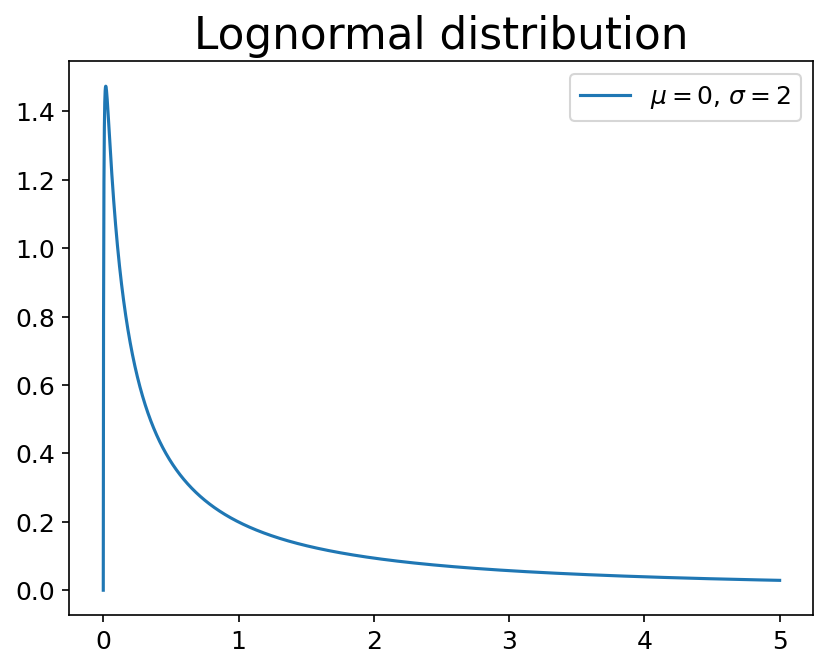

In [10]:
# Распределение считаем маленьким, если распределение его среднего скошено
# То есть, ЦПТ пока не выполнена

dist = stats.lognorm(loc=0, s=2)
x = np.arange(0, 5, 0.001)

plt.plot(x, dist.pdf(x), label='$\\mu=0$, $\\sigma=2$')
plt.title("Lognormal distribution")
plt.legend()
plt.show()

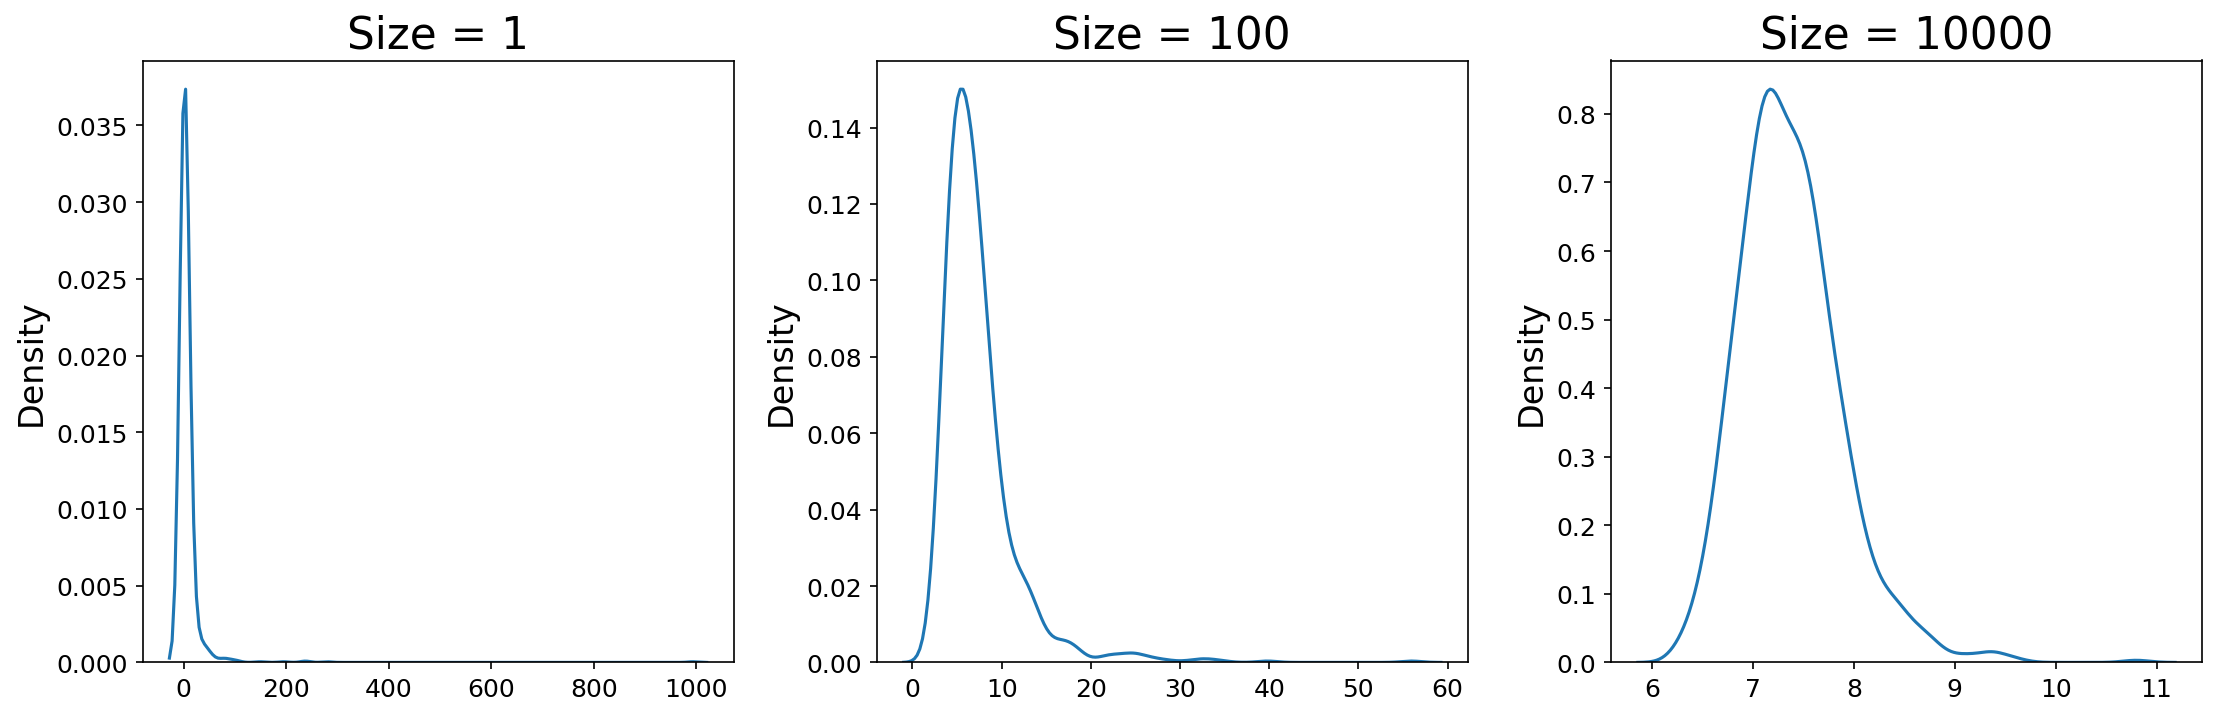

In [21]:
# Посмотрим на распредление среднего от размера выборки

sample_sizes = [1, 100, 10000]

samples = defaultdict(list)

# Run Monte Carlo
n_iter = 1000
for _ in range(n_iter):
    for sz in sample_sizes:
        sample = dist.rvs(sz)
        mean = np.mean(sample)
        samples[f"{sz}"].append(mean)

plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
sns.kdeplot(samples[f"{sample_sizes[0]}"])
plt.title(f"Size = {sample_sizes[0]}")

plt.subplot(1, 3, 2)
sns.kdeplot(samples[f"{sample_sizes[1]}"])
plt.title(f"Size = {sample_sizes[1]}")

plt.subplot(1, 3, 3)
sns.kdeplot(samples[f"{sample_sizes[2]}"])
plt.title(f"Size = {sample_sizes[2]}")

plt.tight_layout()

In [24]:
def plot_pvalue_distribution(dict_pvalues):
    """Рисует графики распределения p-value."""
    X = np.linspace(0, 1, 1000)
    for name, pvalues in dict_pvalues.items():
        # Эмпирическая CDF для pvalue
        Y = [np.mean(np.array(pvalues) < x) for x in X]
        plt.plot(X, Y, label=name)

    plt.plot([0, 1], [0, 1], '--k', alpha=0.8)
    plt.title('Оценка распределения p-value', size=16)
    plt.xlabel('p-value', size=12)
    plt.legend(fontsize=12)
    plt.grid()
    plt.show()

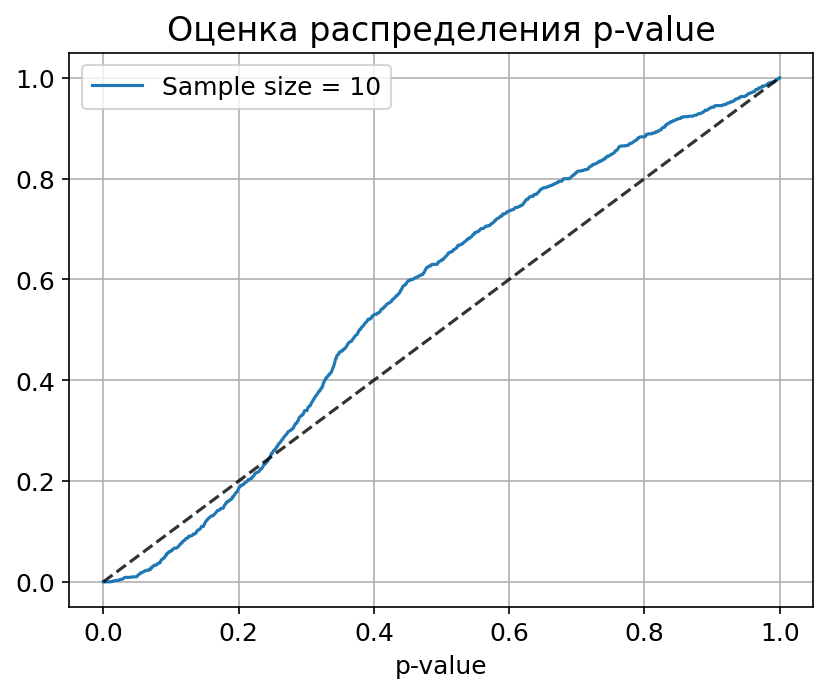

In [25]:
# Проверяем, что для небольших sample_size критерий Стьюдента некорректен 

sample_size = 10

pvalues = []

n_iter = 1000
for _ in range(n_iter):
    control = dist.rvs(sample_size)
    test = dist.rvs(sample_size)

    pvalue = stats.ttest_ind(control, test).pvalue

    pvalues.append(pvalue)

plot_pvalue_distribution({f"Sample size = {sample_size}": pvalues})

Monte Carlo: 100%|██████████| 100000/100000 [00:00<00:00, 2569110.43it/s]


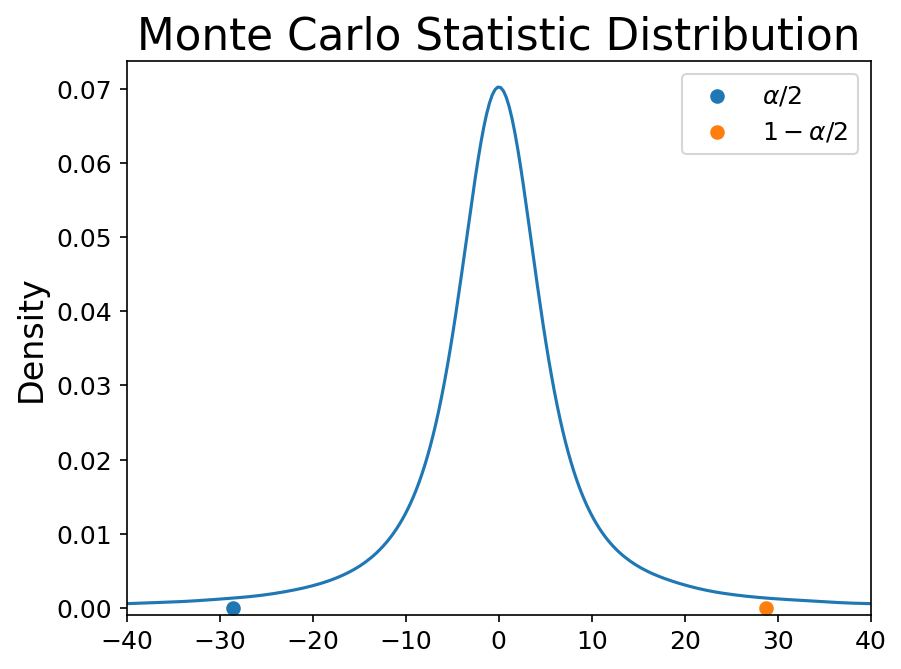

In [46]:
# Теперь сделаем свой критерий 
# C помощью Монте-Карло на исторических данных получим распределение статистики 
# И посчитаем pvalue

def generate_statistic_values(history, sample_size, n_iter):
    num_buckets = len(history) //  (2 * sample_size) # each bucket = control + test

    statistic_list = []
    with tqdm(total=n_iter, desc="Monte Carlo") as pbar:
        while len(statistic_list) < n_iter:
            # Generate maximum numeber of buckets
            sample = np.random.choice(history, (num_buckets, 2 * sample_size), replace=False)
            control = sample[:, :sample_size]
            test = sample[:, sample_size:]

            t = np.mean(test, axis=1) - np.mean(control, axis=1)

            pbar.update(t.size)

            statistic_list += list(t)

        return np.sort(statistic_list[:n_iter])

alpha = 0.05
sample_size = 10
n_iter = 100000
history_size = 1000000

history = stats.lognorm(s=2).rvs(history_size)
statistic_values = generate_statistic_values(history, sample_size, n_iter)

quantiles = np.quantile(statistic_values, [alpha / 2, 1 - alpha / 2])

sns.kdeplot(statistic_values, gridsize=10000)
plt.scatter(quantiles[0], 0, label='$\\alpha/2$')
plt.scatter(quantiles[1], 0, label='$1-\\alpha/2$')
plt.ylim(bottom=-0.001)
plt.xlim(-40, 40)
plt.title('Monte Carlo Statistic Distribution')
plt.legend()

100%|██████████| 10000/10000 [00:02<00:00, 4077.41it/s]


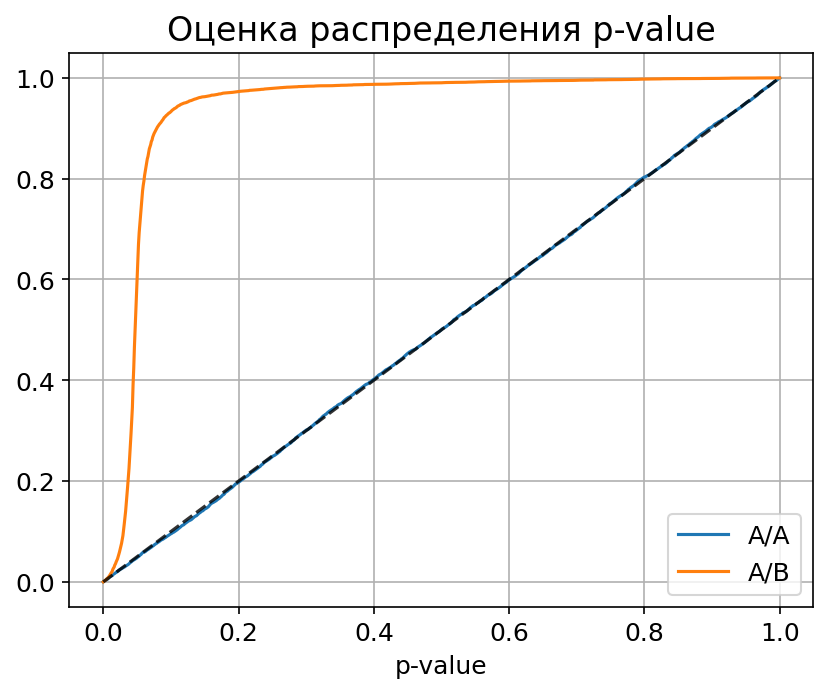

In [47]:
def manual_test(control, test, dist=statistic_values):
    t = np.mean(test) - np.mean(control)

    cdf_left = np.mean(dist <= t)
    cdf_right = 1 - cdf_left

    pvalue = 2 * min(cdf_left, cdf_right)

    return pvalue

effect = 30

dict = defaultdict(list)

# Monte Carlo to get actual TypeOne and Power
n_iter = 10000
for _ in tqdm(range(n_iter)):
    a, b = stats.lognorm(s=2).rvs((2, sample_size))

    pvalue_aa = manual_test(a, b)

    dict['A/A'].append(pvalue_aa)

    b += effect

    pvalue_ab = manual_test(a, b)

    dict['A/B'].append(pvalue_ab)

plot_pvalue_distribution(dict)